In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import gaussian_kde

correlation 확인

In [18]:
# 수요 공급 곡선 불러오기
files = glob.glob("filteredcurve_202507*.csv")
df_list = []

for fn in files:
    temp = pd.read_csv(fn, encoding="utf-8-sig")

    # 파일명에서 날짜 추출
    date_str = fn.split("_")[-1].split(".")[0]   # 예: "20250720"
    temp["Date"] = pd.to_datetime(date_str, format="%Y%m%d")

    # Hour (Time Period → Hour)
    temp = temp.dropna(subset=["Time Period"])
    temp["Hour"] = temp["Time Period"].astype(int)

    # Datetime (포맷: YYYYMMDD H)
    temp["Datetime"] = temp["Date"].dt.strftime("%Y%m%d") + " " + temp["Hour"].astype(str)

    df_list.append(temp)

df_supply = pd.concat(df_list, ignore_index=True)

print(df_supply[["Date", "Hour", "Datetime"]].head())

        Date  Hour    Datetime
0 2025-07-01     1  20250701 1
1 2025-07-01     1  20250701 1
2 2025-07-01     1  20250701 1
3 2025-07-01     1  20250701 1
4 2025-07-01     1  20250701 1


In [12]:
supply_curves = []

for (date, hour), sub in df_supply.groupby(["Date", "Hour"]):
    sup = sub[sub["GC"] == "V"].copy()   # 공급
    dem = sub[sub["GC"] == "C"].copy()   # 수요
    if sup.empty or dem.empty:
        continue
    
    # 공급곡선 집계
    s_agg = sup.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    s_agg["Cumul"] = s_agg["Amount"].cumsum()
    
    # 수요곡선 집계
    d_agg = dem.groupby("Price")["Amount"].sum().reset_index().sort_values("Price")
    d_agg["Cumul"] = d_agg["Amount"][::-1].cumsum()[::-1]
    
    # Datetime
    dt = pd.to_datetime(date).strftime("%Y%m%d") + " " + str(hour)
    
    supply_curves.append({
        "Datetime": dt,
        "Supply": s_agg,
        "Demand": d_agg
    })

print(len(supply_curves), "curves loaded")

696 curves loaded


In [ ]:
# 예시: df_weather.csv, df_forecast.csv 파일 있다고 가정
df_weather = pd.read_csv("weather_transformed.csv")

file_path = "demandforecast0903.xls"
dfs = pd.read_html(file_path)
read_type = "html"
df_forecast = dfs[0]
# 전처리: '----' → NaN, 숫자 변환
# df_weather = df_weather.replace("----", np.nan)
df_weather[["T","ff","Prec"]] = df_weather[["T","ff","Prec"]].apply(pd.to_numeric, errors="coerce")

print(df_weather.head())
print(df_forecast.head())


         Date      Time     T    Td  Hr   Tmax   Tmin  ddd    ff   Gust  ...  \
0         NaN       NaN   NaN   (C)   %    (C)    (C)  NaN   NaN    max  ...   
1  31/07/2025  23:00:00  25.7  10.2  38  -----  -----  NNW  13.0  948.8  ...   
2  31/07/2025  22:00:00  26.0  10.3  37  -----  -----    N  11.1  948.6  ...   
3  31/07/2025  21:00:00  27.0   9.4  33  -----  -----  ENE   7.4  948.1  ...   
4  31/07/2025  20:00:00  29.0  10.5  32  -----  -----    N   9.3  947.6  ...   

  Prec  N  N.1    H Inso  Vis  WW  W1  W2  Hour  
0  NaN  t    h   Km  D-1   km NaN NaN NaN   NaN  
1  1.0  0  2.5  ---   30  NaN NaN NaN NaN  24.0  
2  3.0  1  ---  ---   30  NaN NaN NaN NaN  23.0  
3  1.0  0  2.5  ---   30  NaN NaN NaN NaN  22.0  
4  2.0  1  ---  ---   30  NaN NaN NaN NaN  21.0  

[5 rows x 23 columns]
      0                          1      2        3          4  \
0    id                       name  geoid  geoname      value   
1  1775  Demand D+1 daily forecast    NaN      NaN  37552.500   
2

In [16]:
# Hour → 숫자로 변환 (변환 불가는 NaN)
df_weather["Hour"] = pd.to_numeric(df_weather["Hour"], errors="coerce")

# NaN 값 제거
df_weather = df_weather.dropna(subset=["Hour"])

# int 변환
df_weather["Hour"] = df_weather["Hour"].astype(int)

# Date를 datetime으로 변환
df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce")

# Datetime 생성: "20250731 13"
df_weather["Datetime"] = df_weather["Date"].dt.strftime("%Y%m%d") + " " + df_weather["Hour"].astype(str)

df_weather["Weekday"] = df_weather["Date"].dt.weekday  

# 주말 여부 (토=5, 일=6 → True)
df_weather["IsWeekend"] = df_weather["Weekday"].isin([5, 6])

print(df_weather[["Date", "Hour", "Datetime", "Weekday", "IsWeekend"]].head(100))

          Date  Hour     Datetime  Weekday  IsWeekend
1   2025-07-31    24  20250731 24        3      False
2   2025-07-31    23  20250731 23        3      False
3   2025-07-31    22  20250731 22        3      False
4   2025-07-31    21  20250731 21        3      False
5   2025-07-31    20  20250731 20        3      False
..         ...   ...          ...      ...        ...
97  2025-07-28     1   20250728 1        0      False
98  2025-07-27    24  20250727 24        6       True
99  2025-07-27    23  20250727 23        6       True
100 2025-07-27    22  20250727 22        6       True
101 2025-07-27    21  20250727 21        6       True

[100 rows x 5 columns]


C:\Users\symply_jina\AppData\Local\Temp\ipykernel_21424\803270465.py:11: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_weather["Date"] = pd.to_datetime(df_weather["Date"], errors="coerce")


In [17]:
# 1. 컬럼 정리 (첫 행이 컬럼명이면 이 과정 필요)
df_forecast.columns = df_forecast.iloc[0]   # 첫 번째 행을 컬럼명으로
df_forecast = df_forecast.drop(0).reset_index(drop=True)

# 2. datetime 처리
df_forecast["datetime"] = pd.to_datetime(df_forecast["datetime"], errors="coerce")

# 3. Date와 Hour 분리
df_forecast["Date"] = df_forecast["datetime"].dt.strftime("%Y%m%d")   # YYYYMMDD 문자열
df_forecast["Hour"] = df_forecast["datetime"].dt.hour + 1             # 0~23 → 1~24

# 4. Datetime: "20250701 1" 형태로
df_forecast["Datetime"] = df_forecast["Date"] + " " + df_forecast["Hour"].astype(str)

# 5. value를 숫자로 변환
df_forecast["value"] = pd.to_numeric(df_forecast["value"], errors="coerce")

# 확인
print(df_forecast[["Date", "Hour", "Datetime", "value"]].head(10))
print(df_forecast.dtypes)


0      Date  Hour     Datetime    value
0  20250630    18  20250630 18  37552.5
1  20250630    19  20250630 19  37571.8
2  20250630    20  20250630 20  37861.0
3  20250630    21  20250630 21  37543.0
4  20250630    22  20250630 22  37057.8
5  20250630    23  20250630 23  35464.8
6  20250630    24  20250630 24  32630.3
7  20250701     1   20250701 1  31178.3
8  20250701     2   20250701 2  29220.3
9  20250701     3   20250701 3  27816.3
0
id                             object
name                           object
geoid                          object
geoname                        object
value                         float64
datetime    datetime64[ns, UTC+02:00]
Date                           object
Hour                            int32
Datetime                       object
dtype: object


In [30]:
records = []
for cur in supply_curves:
    dt = cur["Datetime"]
    date = pd.to_datetime(dt.split()[0])
    hour = int(dt.split()[1])
    dow = date.dayofweek   # 요일

    # 날씨 매칭 (Date 기준)
    w_row = df_weather[df_weather["Date"] == date.strftime("%Y-%m-%d")]
    if w_row.empty:
        continue
    w_row = w_row.iloc[0]
    T, ff, Prec = w_row["T"], w_row["ff"], w_row["Prec"]

    # 수요 매칭 (Datetime 기준)
    f_row = df_forecast[df_forecast["Datetime"] == dt]
    if f_row.empty:
        continue
    demand_val = float(f_row.iloc[0]["value"])

    # 공급/수요 요약값
    s, d = cur["Supply"], cur["Demand"]
    sup_meanP = s["Price"].mean()
    sup_maxQ = s["Cumul"].max()
    dem_meanP = d["Price"].mean()
    dem_maxQ = d["Cumul"].max()

    # 균형점 계산
    fS = interp1d(s["Price"], s["Cumul"], kind="previous",
                  bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
    fD = interp1d(d["Price"], d["Cumul"], kind="previous",
                  bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
    P = np.linspace(max(s["Price"].min(), d["Price"].min()),
                    min(s["Price"].max(), d["Price"].max()), 300)
    sv, dv = fS(P), fD(P)
    resid = dv - sv
    flip = np.where(np.diff(np.sign(resid)) != 0)[0]
    if len(flip):
        eq_P = P[flip[0]]
        eq_Q = (sv[flip[0]] + dv[flip[0]]) / 2
    else:
        eq_P, eq_Q = np.nan, np.nan

    records.append({
        "Datetime": dt,
        "DayOfWeek": dow,
        "T": T, "ff": ff, "Prec": Prec,
        "DemandForecast": demand_val,
        "SupplyMeanP": sup_meanP, "SupplyMaxQ": sup_maxQ,
        "DemandMeanP": dem_meanP, "DemandMaxQ": dem_maxQ,
        "EqPrice": eq_P, "EqQuantity": eq_Q
    })

df_combined = pd.DataFrame(records)
print(df_combined.head())


     Datetime  DayOfWeek     T    ff  Prec  DemandForecast  SupplyMeanP  \
0  20250701 1          1  28.8  13.0   NaN         31178.3   105.974511   
1  20250701 2          1  28.8  13.0   NaN         29220.3    99.965739   
2  20250701 3          1  28.8  13.0   NaN         27816.3   100.357077   
3  20250701 4          1  28.8  13.0   NaN         26997.3   100.792631   
4  20250701 5          1  28.8  13.0   NaN         26562.8   101.131680   

   SupplyMaxQ  DemandMeanP  DemandMaxQ     EqPrice  EqQuantity  
0     79230.0   160.459833     56662.1  116.076923    51335.35  
1     78517.7   155.584590     54560.8  109.391304    46440.05  
2     76283.8   154.773967     51696.0  109.391304    44585.20  
3     75164.2   154.467869     49898.1  109.391304    43809.35  
4     74383.1   154.749227     48842.5  109.391304    43129.55  


In [33]:
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i],       resid[i+1]
            if r1 != r0:
                # 선형 보간으로 교차점 계산
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc


In [40]:
# rdc 포함
records = []
for cur in supply_curves:
    dt = cur["Datetime"]
    date = pd.to_datetime(dt.split()[0])
    hour = int(dt.split()[1])
    dow = date.dayofweek   # 요일

    # 날씨 매칭 (Date 기준)
    w_row = df_weather[df_weather["Date"] == date.strftime("%Y-%m-%d")]
    if w_row.empty:
        continue
    w_row = w_row.iloc[0]
    T, ff, Prec = w_row["T"], w_row["ff"], w_row["Prec"]

    # 수요 매칭 (Datetime 기준)
    f_row = df_forecast[df_forecast["Datetime"] == dt]
    if f_row.empty:
        continue
    demand_val = float(f_row.iloc[0]["value"])

    # 공급/수요 곡선 요약
    s, d = cur["Supply"], cur["Demand"]
    sup_meanP = s["Price"].mean()
    sup_maxQ = s["Cumul"].max()
    dem_meanP = d["Price"].mean()
    dem_maxQ = d["Cumul"].max()

    # 균형점 계산
    fS = interp1d(s["Price"], s["Cumul"], kind="previous",
                  bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
    fD = interp1d(d["Price"], d["Cumul"], kind="previous",
                  bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
    P = np.linspace(max(s["Price"].min(), d["Price"].min()),
                    min(s["Price"].max(), d["Price"].max()), 300)
    sv, dv = fS(P), fD(P)
    resid = dv - sv
    flip = np.where(np.diff(np.sign(resid)) != 0)[0]
    if len(flip):
        eq_P = P[flip[0]]
        eq_Q = (sv[flip[0]] + dv[flip[0]]) / 2
    else:
        eq_P, eq_Q = np.nan, np.nan

    # === RDC 계산 ===
    wf_offer_grid = np.arange(0, sup_maxQ*1.2, 500)  # 풍력 가정량 grid
    rdc_pts = compute_rdc_by_sign_change(P, dv, sv, wf_offer_grid)

    if rdc_pts:
        q_rdc, p_rdc = zip(*rdc_pts)
        rdc_meanP = np.mean(p_rdc)
        rdc_minP  = np.min(p_rdc)
        rdc_maxP  = np.max(p_rdc)
    else:
        rdc_meanP, rdc_minP, rdc_maxP = np.nan, np.nan, np.nan

    records.append({
        "Datetime": dt,
        "DayOfWeek": dow,
        "T": float(T), "ff": float(ff), "Prec": float(Prec),
        "DemandForecast": demand_val,
        "SupplyMeanP": sup_meanP, "SupplyMaxQ": sup_maxQ,
        "DemandMeanP": dem_meanP, "DemandMaxQ": dem_maxQ,
        "EqPrice": eq_P, "EqQuantity": eq_Q,
        "RDC_MeanP": rdc_meanP, "RDC_MinP": rdc_minP, "RDC_MaxP": rdc_maxP # 전체 곡선도 원하면 저장 가능
    })

df_combined = pd.DataFrame(records)
print(df_combined.head())


     Datetime  DayOfWeek     T    ff  Prec  DemandForecast  SupplyMeanP  \
0  20250701 1          1  28.8  13.0   NaN         31178.3   105.974511   
1  20250701 2          1  28.8  13.0   NaN         29220.3    99.965739   
2  20250701 3          1  28.8  13.0   NaN         27816.3   100.357077   
3  20250701 4          1  28.8  13.0   NaN         26997.3   100.792631   
4  20250701 5          1  28.8  13.0   NaN         26562.8   101.131680   

   SupplyMaxQ  DemandMeanP  DemandMaxQ     EqPrice  EqQuantity  RDC_MeanP  \
0     79230.0   160.459833     56662.1  116.076923    51335.35  47.299414   
1     78517.7   155.584590     54560.8  109.391304    46440.05  44.875424   
2     76283.8   154.773967     51696.0  109.391304    44585.20  43.785970   
3     75164.2   154.467869     49898.1  109.391304    43809.35  39.889328   
4     74383.1   154.749227     48842.5  109.391304    43129.55  38.250156   

     RDC_MinP    RDC_MaxP  
0 -100.961594  119.159037  
1 -118.075730  115.884864  
2 

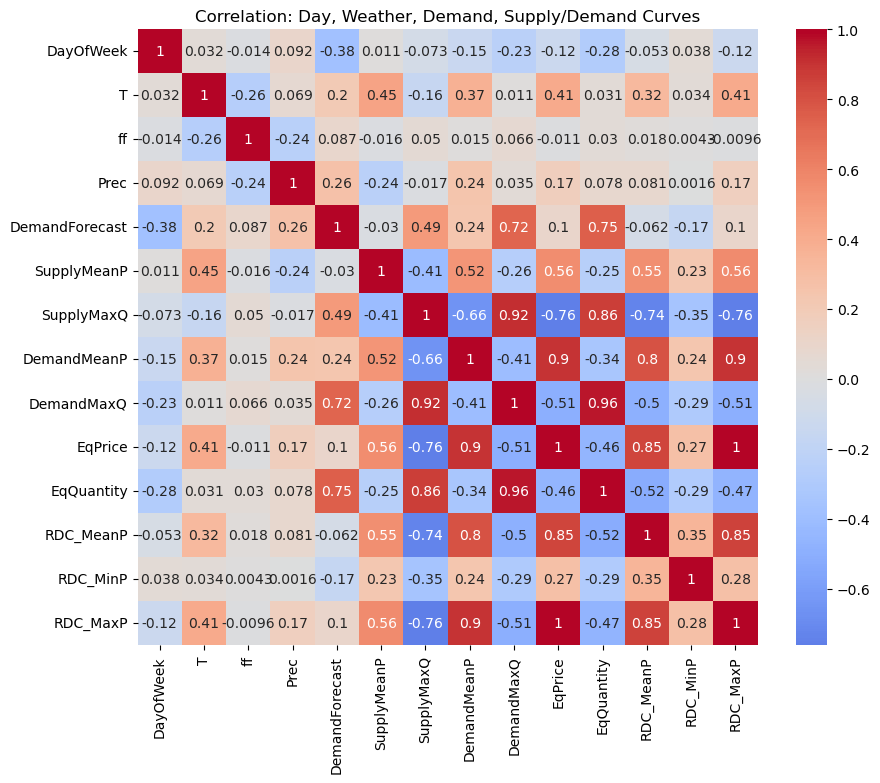

In [41]:
corr = df_combined.drop(columns=["Datetime"]).corr(method="pearson")

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: Day, Weather, Demand, Supply/Demand Curves")
plt.show()

In [45]:
import statsmodels.api as sm

# 회귀 데이터 준비
X = df_combined[["T", "ff", "Prec", "DemandForecast"]]
y = df_combined["EqPrice"]
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

data = pd.concat([X, y], axis=1).dropna()
X = data[X.columns]
y = data[y.name]

# 상수항 추가
X = sm.add_constant(X)

# 선형회귀
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                EqPrice   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     37.26
Date:                Fri, 05 Sep 2025   Prob (F-statistic):           3.79e-28
Time:                        17:18:59   Log-Likelihood:                -3411.2
No. Observations:                 672   AIC:                             6832.
Df Residuals:                     667   BIC:                             6855.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -112.2191     17.887     -6.

In [44]:
print(X.isna().sum())       # NaN 개수
print(np.isinf(X).sum())    # inf 개수


const              0
T                  0
ff                 0
Prec              24
DemandForecast     0
dtype: int64
const             0
T                 0
ff                0
Prec              0
DemandForecast    0
dtype: int64


In [28]:
records = []
for cur in supply_curves:
    dt = cur["Datetime"]
    date = pd.to_datetime(dt.split()[0])
    hour = int(dt.split()[1])
    dow = date.dayofweek   # 0=월 ~ 6=일

    # --- 요일 그룹화 ---
    if dow in [0, 4, 5, 6]:   # 월, 금, 토, 일
        day_group = "FriSatSunMon"
    else:                     # 화, 수, 목
        day_group = "TueWedThu"

    # 날씨 매칭 (Date 기준)
    w_row = df_weather[df_weather["Date"] == date.strftime("%Y-%m-%d")]
    if w_row.empty:
        continue
    w_row = w_row.iloc[0]
    T, ff, Prec = pd.to_numeric(w_row[["T","ff","Prec"]], errors="coerce")

    # 수요 매칭 (Datetime 기준)
    f_row = df_forecast[df_forecast["Datetime"] == dt]
    if f_row.empty:
        continue
    demand_val = float(f_row.iloc[0]["value"])

    # 공급/수요 요약값
    s, d = cur["Supply"], cur["Demand"]
    sup_meanP = s["Price"].mean()
    sup_maxQ = s["Cumul"].max()
    dem_meanP = d["Price"].mean()
    dem_maxQ = d["Cumul"].max()

    # 균형점 계산
    fS = interp1d(s["Price"], s["Cumul"], kind="previous",
                  bounds_error=False, fill_value=(0, s["Cumul"].iat[-1]))
    fD = interp1d(d["Price"], d["Cumul"], kind="previous",
                  bounds_error=False, fill_value=(d["Cumul"].iat[0], 0))
    P = np.linspace(max(s["Price"].min(), d["Price"].min()),
                    min(s["Price"].max(), d["Price"].max()), 300)
    sv, dv = fS(P), fD(P)
    resid = dv - sv
    flip = np.where(np.diff(np.sign(resid)) != 0)[0]
    if len(flip):
        eq_P = P[flip[0]]
        eq_Q = (sv[flip[0]] + dv[flip[0]]) / 2
    else:
        eq_P, eq_Q = np.nan, np.nan

    records.append({
        "Datetime": dt,
        "DayGroup": day_group,   # 요일 그룹 추가
        "T": T, "ff": ff, "Prec": Prec,
        "DemandForecast": demand_val,
        "SupplyMeanP": sup_meanP, "SupplyMaxQ": sup_maxQ,
        "DemandMeanP": dem_meanP, "DemandMaxQ": dem_maxQ,
        "EqPrice": eq_P, "EqQuantity": eq_Q
    })

df_combined = pd.DataFrame(records)
